In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [ ]:
data = pd.read_csv('https://tinyurl.com/ChrisCoDV/001260070/OutletDailyCustomers.csv', index_col=0)
data.index = pd.to_datetime(data.index)
print(data.head())
print(data.describe())

            LRT   QXC  YRY  SRZ  NLQ  KFO  UXT  LXE  NRB  MFY  ...   VUJ  XMU  \
Date                                                           ...              
2023-01-01   71  1150   82   91  789    0   59   74    0    0  ...  1870   58   
2023-01-02   89   937   88   74  684    0   82   46    0    0  ...  2067   67   
2023-01-03   49  1015   82  103  695    0   74   57    0    0  ...  2030   80   
2023-01-04   67   748   76   98  592    0   57   74    0    0  ...  1719   75   
2023-01-05   71   685   65   63  483    0   80   54    0    0  ...  1442   76   

            KLZ  SXK  PRK  VXB  ZER  ASW  WRQ  AYH  
Date                                                
2023-01-01   73   88  857   64   62   79   51   65  
2023-01-02   72   77  807   78   67   88   58   97  
2023-01-03   59   87  712   97   57   77   67   71  
2023-01-04   84   80  581  114   56   82   63   94  
2023-01-05   85  103  682   97   71   82   58  105  

[5 rows x 45 columns]
              LRT          QXC        

In [ ]:
outlet_marketing = pd.read_csv('https://tinyurl.com/ChrisCoDV/001260070/OutletMarketing.csv', index_col=0)
outlet_overhead = pd.read_csv('https://tinyurl.com/ChrisCoDV/001260070/OutletOverheads.csv', index_col=0)
outlet_size = pd.read_csv('https://tinyurl.com/ChrisCoDV/001260070/OutletSize.csv', index_col=0)
outlet_staff = pd.read_csv('https://tinyurl.com/ChrisCoDV/001260070/OutletStaff.csv ', index_col=0)

In [ ]:
summary_data = pd.DataFrame(index=data.columns)
summary_data['Marketing'] = outlet_marketing.values
summary_data['Overhead'] = outlet_overhead.values
summary_data['Size'] = outlet_size.values
summary_data['Staff'] = outlet_staff.values
print(summary_data.head(45))
print(summary_data.describe())

     Marketing  Overhead  Size  Staff
LRT       2000     66000    97      1
QXC      27000     91000  2594     18
YRY       3000     79000   166      2
SRZ       3000     77000   221      2
NLQ      25000     89000  2227     19
KFO       1000     93000    38      1
UXT       3000     25000   192      2
LXE       2000     54000    69      1
NRB       1000     24000    34      1
MFY       2000     59000    65      1
ZKE       3000     84000   285      2
LLJ       2000     97000    59      1
XXJ       3000     48000   264      2
RLH       2000     79000    75      1
MXL       1000     56000    75      1
QRS      30000     91000  1995     11
PLY      37000     75000  2031     16
XDV       2000     79000   140      2
WJG       2000     39000    67      1
TLP       3000     98000   147      2
VAU      73000     12000  4378     30
XEK       3000     88000   252      3
UOR      72000     84000  3610     40
OFF      31000     99000  2638     28
PFN      33000     82000  1466     10
RDX       30

In [ ]:
total_customers = data.sum()
sorted_customers = total_customers.sort_values(ascending=False)
print(sorted_customers)

UOR    753343
VUJ    714859
VAU    694582
PFN    359529
QRS    354711
PLY    336217
QXC    317718
OFF    293727
NLQ    265423
PRK    263235
VXB     33759
ZKE     32872
SRZ     32799
ASW     32110
SXK     31511
BEB     31389
TDE     29905
AYH     29800
YRY     29721
TLP     29465
URJ     28937
XEK     28926
BKL     28695
XXJ     28664
UXT     26946
CSD     26271
XMU     26095
VDM     25491
ULW     24835
CYQ     23774
ZER     22813
RLH     22800
RDX     22030
WRQ     21543
LRT     18166
LXE     16622
XDV     16599
WJG     16121
LLJ     13794
MFY     10220
KFO      9904
MXL      8505
OXV      6754
KLZ      6529
NRB      3897
dtype: int64


Figure 1: L02 Proportion - Bar Chart All Coloured

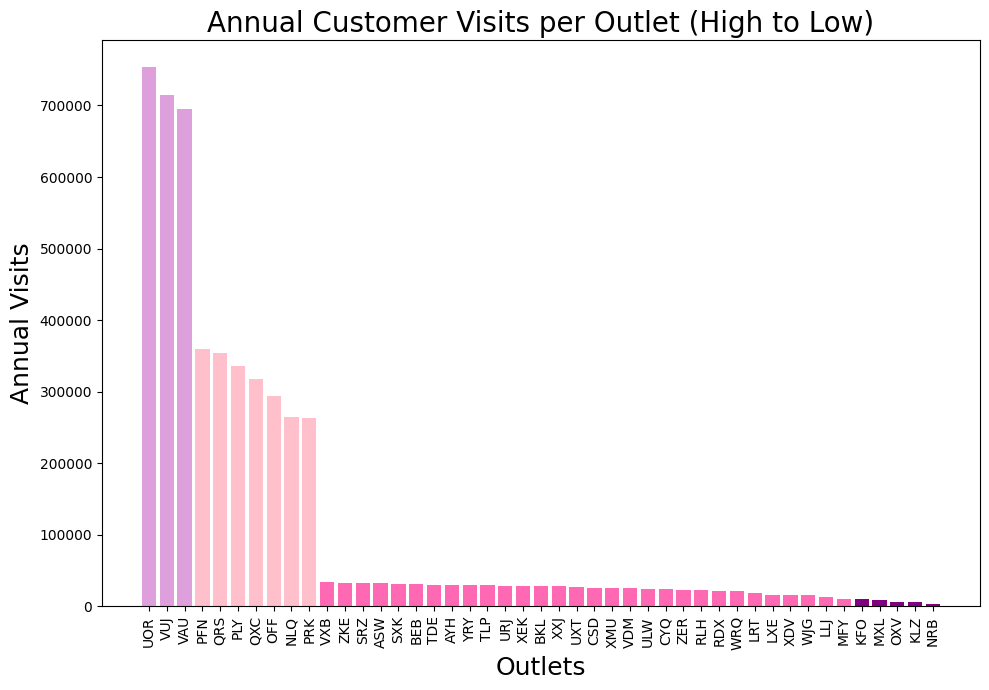

In [ ]:
total_visits = data.sum()
segment_limits = {
    0: 'Very Low',
    10_000: 'Low',
    200_000: 'Medium',
    500_000: 'High',
}

segment_colours = {
    'Very Low': 'purple',
    'Low': 'hotpink',
    'Medium': 'pink',
    'High': 'plum',
}


def get_segment(value):
    if value >= 500_000:
        return 'High'
    elif value >= 200_000:
        return 'Medium'
    elif value >= 10_000:
        return 'Low'
    else:
        return 'Very Low'

total_visits_sorted = total_visits.sort_values(ascending=False)
colours = [segment_colours[get_segment(value)] for value in total_visits_sorted]

plt.figure(figsize=(10, 7))
x_pos = np.arange(len(total_visits_sorted))
plt.bar(x_pos, total_visits_sorted.values, align='center', color=colours)
plt.xticks(x_pos, total_visits_sorted.index, rotation=90)
plt.xlabel('Outlets', fontsize=18)
plt.ylabel('Annual Visits', fontsize=18)
plt.title('Annual Customer Visits per Outlet (High to Low)', fontsize=20)
plt.tight_layout()
plt.show()

Figure 2: L07 Interactive - LIne Plot Rolling Average

In [ ]:
!pip install hvplot

import hvplot.pandas
import holoviews as hv

data.index = pd.to_datetime(data.index)
averaged_data = data.rolling(window=7).mean()

plot = averaged_data.hvplot.line(
    frame_height=500, frame_width=900,
    xlabel='Date', ylabel='Customer Visits (Daily)',
    title='Daily Customer Visits per Outlet with 7-Day Rolling Average 2023'
)

hv.extension('bokeh')
plot

:NdOverlay   [Variable]
   :Curve   [Date]   (value)

#Markdown Figure 2: Interactive Line Plot-User Guide:

This visualisation shows the number of daily customer visits to all 45 ChrisCo outlets across 2023 by using a seven-day rolling average. The chart is fully interactive using the Bokeh toolbar displayed on the right-hand side.

##!!!!!!Please open this file through Google Colab! The interactivity is applied on the Google Colab notebook and would need changes to open through a different portal.!!!!!

###Instructions for users:

Zoom:  
* Scroll up with your mouse wheel to zoom in on any seasonal area.
* Alternatively, click the zoom box icon in the toolbar, then draw a box around the area you want to examine.
* This is especially useful for isolating specific months and seasons to see peeks or lows.

Pan:   
* Click the hand icon in the toolbar.
* Click and drag the chart left or right to move across the year.
* Use this feature after zooming in to follow trends month by month.

Hover:
* Move your mouse slowly over any line.
* A tooltip will appear showing the outlet name, the exact date and the smoothed daily visit value at that point.
* This is the best way to identify individual outlets in the crowded lower performance bands.

Reset:
* Click the circular reset icon in the toolbar at any time.
* This will return the chart to the original full-year view.

Legend filtering:
* Click on any outlet name in the legend on the right-hand side.
* This will hide or show that outlet's line.
* Use this to isolate specific outlets or volume groups for direct comparison.

###Suggested Exploration Steps:
1. Start with the full view and observe the three volumes of the outlet/different performace categories (high, medium, low/very low volume).
2. Hover over the top three lines to confirm the different outlets of UOR, VUJ and VAU(ChrisCo's high-volume outlets).
3. Zoom into July 2023 and hover over the VAU line to observe its dips and peaks compared to UOR and VUJ, which remain stable.
4. Zoom into June and December 2023 to confirm VAU's seasonal peaks. It is the main outlet showing significant seasonal sensitivity.
5. Use legend filtering to hide all outlets except the seven medium-volume ones (PFN, QRS, PLY, QXC, OFF, NLQ and PRK), and compare their patterns directly.
6. Zoom into the bottom of the chart and hover over the zero lines at the start or end of the year to identify which outlets opened or closed in 2023.





Figure 3: L03 Time - Line Plot averaged (opened & closed)

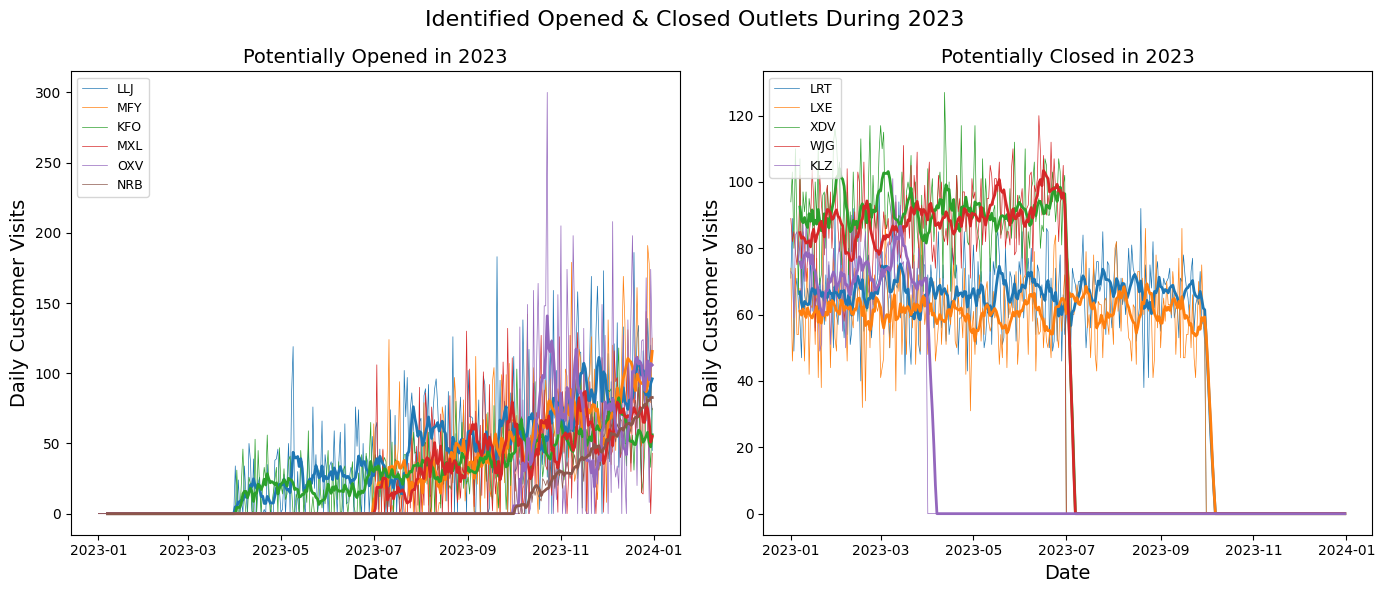

In [ ]:
new_outlets = ['LLJ', 'MFY', 'KFO', 'MXL', 'OXV', 'NRB']
closed_outlets = ['LRT', 'LXE', 'XDV', 'WJG', 'KLZ']

fig = plt.figure(figsize=(14, 6))
fig.suptitle('Identified Opened & Closed Outlets During 2023', fontsize=16)


plt.subplot(1, 2, 1)
plt.plot(data[new_outlets], linewidth=0.5)
plt.gca().set_prop_cycle(None)
plt.plot(data[new_outlets].rolling(window=7).mean(), linewidth=2)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily Customer Visits', fontsize=14)
plt.title('Potentially Opened in 2023', fontsize=14)
plt.legend(new_outlets, loc=2, fontsize=9)

plt.subplot(1, 2, 2)
plt.plot(data[closed_outlets], linewidth=0.5)
plt.gca().set_prop_cycle(None)
plt.plot(data[closed_outlets].rolling(window=7).mean(), linewidth=2)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Daily Customer Visits', fontsize=14)
plt.title('Potentially Closed in 2023', fontsize=14)
plt.legend(closed_outlets, loc=2, fontsize=9)

plt.tight_layout()
plt.show()

Figure 4: L05 Distribution - Box Plots

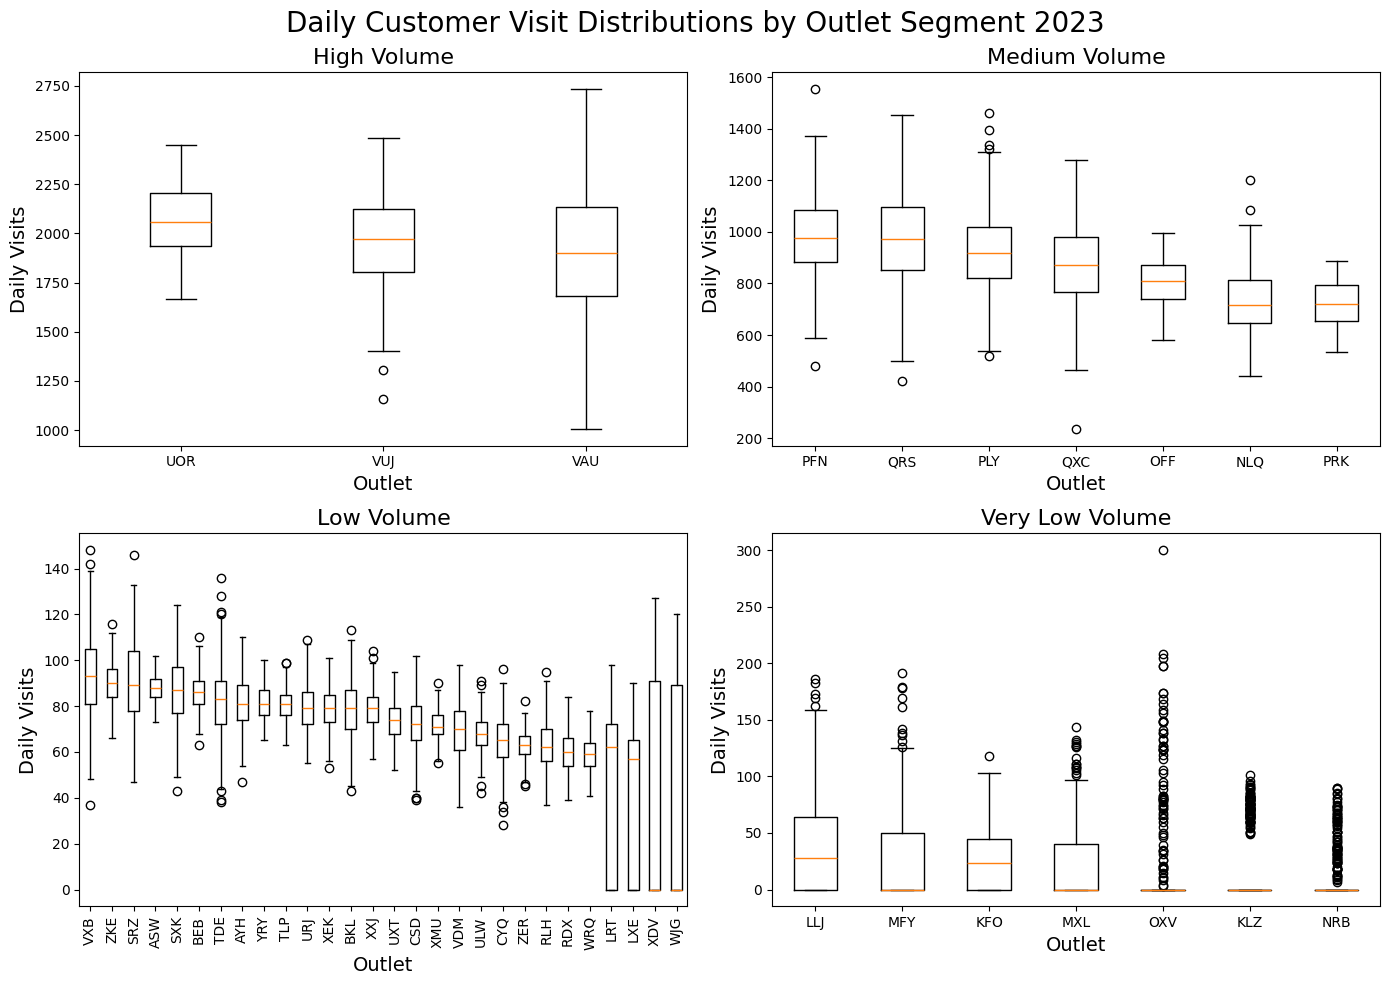

In [ ]:
high = ['UOR', 'VUJ', 'VAU']
medium = ['PFN', 'QRS', 'PLY', 'QXC', 'OFF', 'NLQ', 'PRK']
low = ['VXB', 'ZKE', 'SRZ', 'ASW', 'SXK', 'BEB', 'TDE', 'AYH', 'YRY', 'TLP', 'URJ', 'XEK', 'BKL', 'XXJ', 'UXT', 'CSD', 'XMU', 'VDM', 'ULW', 'CYQ', 'ZER', 'RLH', 'RDX', 'WRQ', 'LRT', 'LXE', 'XDV', 'WJG']
very_low = ['LLJ', 'MFY', 'KFO', 'MXL', 'OXV', 'KLZ', 'NRB']

plt.figure(figsize=(14, 10))
plt.suptitle('Daily Customer Visit Distributions by Outlet Segment 2023', fontsize=20)

plt.subplot(2, 2, 1)
plt.boxplot(data[high], tick_labels=high)
plt.xlabel('Outlet', fontsize=14)
plt.ylabel('Daily Visits', fontsize=14)
plt.title('High Volume', fontsize=16)

plt.subplot(2, 2, 2)
plt.boxplot(data[medium], tick_labels=medium)
plt.xlabel('Outlet', fontsize=14)
plt.ylabel('Daily Visits', fontsize=14)
plt.title('Medium Volume', fontsize=16)

plt.subplot(2, 2, 3)
plt.boxplot(data[low], tick_labels=low)
plt.xlabel('Outlet', fontsize=14)
plt.ylabel('Daily Visits', fontsize=14)
plt.title('Low Volume', fontsize=16)
plt.xticks(rotation=90)

plt.subplot(2, 2, 4)
plt.boxplot(data[very_low], tick_labels=very_low)
plt.xlabel('Outlet', fontsize=14)
plt.ylabel('Daily Visits', fontsize=14)
plt.title('Very Low Volume', fontsize=16)

plt.tight_layout()
plt.show()

Figure 5: L04 Correlation - Heatmap (High&Medium Volume)

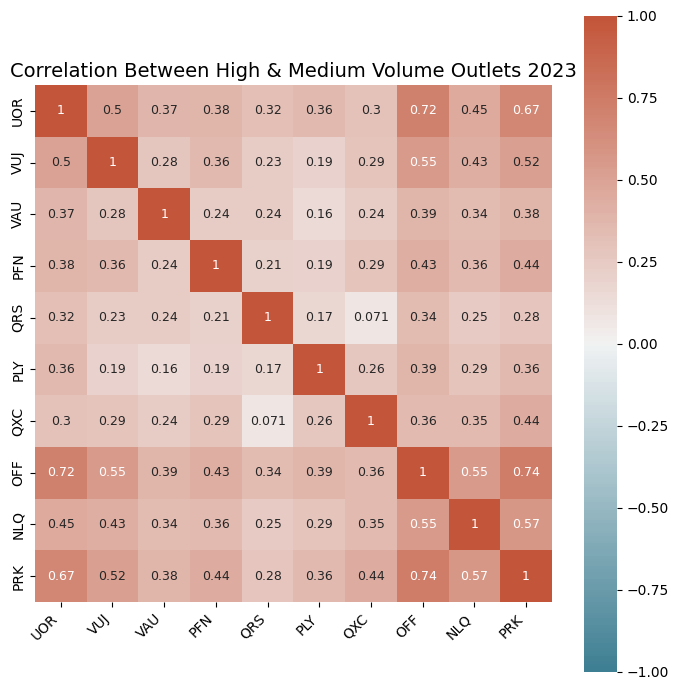

In [ ]:
selected = ['UOR', 'VUJ', 'VAU', 'PFN', 'QRS', 'PLY', 'QXC', 'OFF', 'NLQ', 'PRK']

plt.figure(figsize=(7, 7))
corr = data[selected].corr()
ax = sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(220, 20, n=200), square=True, annot=True, annot_kws={"size": 9})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.title('Correlation Between High & Medium Volume Outlets 2023', fontsize=14)
plt.tight_layout()
plt.show()

Figure 6: L06 Dimension - Correlogram/Pair Plot

     Marketing  Overhead  Size Outlet  Amount Staff  Annual Visits
LRT       2000     66000           97             1          18166
QXC      27000     91000         2594            18         317718
YRY       3000     79000          166             2          29721
SRZ       3000     77000          221             2          32799
NLQ      25000     89000         2227            19         265423
          Marketing      Overhead  Size Outlet  Amount Staff  Annual Visits
count     45.000000     45.000000    45.000000     45.000000      45.000000
mean   11377.777778  66155.555556   740.311111      6.600000  114480.133333
std    18618.525585  27287.988996  1280.318902     11.068793  195814.676557
min     1000.000000  12000.000000    25.000000      1.000000    3897.000000
25%     2000.000000  39000.000000    97.000000      1.000000   21543.000000
50%     3000.000000  79000.000000   183.000000      2.000000   28695.000000
75%     4000.000000  89000.000000   285.000000      3.000000   328

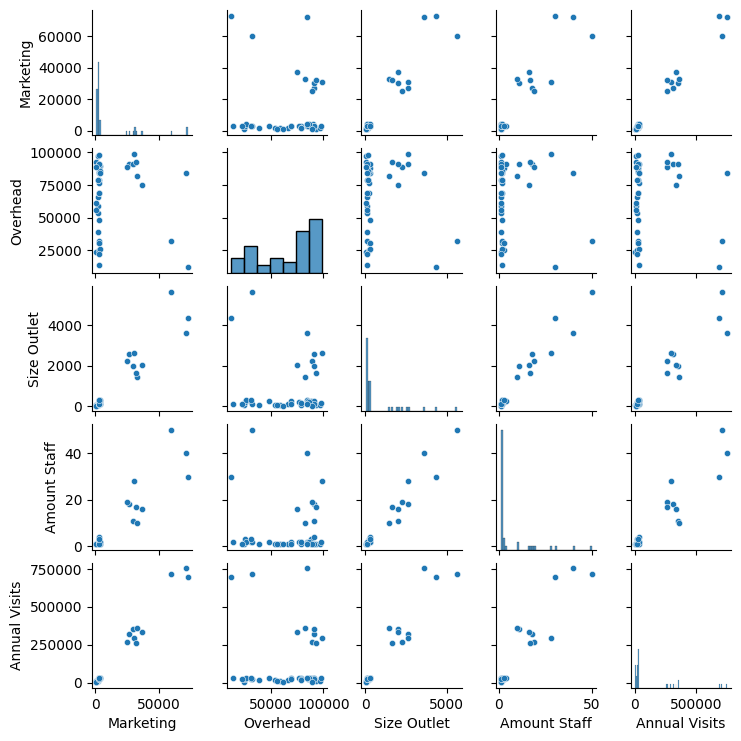

In [ ]:
summary_data = pd.DataFrame(index=data.columns)
summary_data['Marketing'] = outlet_marketing.values
summary_data['Overhead'] = outlet_overhead.values
summary_data['Size Outlet'] = outlet_size.values
summary_data['Amount Staff'] = outlet_staff.values
summary_data['Annual Visits'] = data.sum().values

print(summary_data.head())
print(summary_data.describe())

sns.pairplot(summary_data, height=1.5, plot_kws={'s': 20})
plt.show()

Figure 7: L06 Dimension - Radar Plot (High & Medium Volume)

     Marketing  Overhead  Size Outlet  Amount Staff  Annual Visits
LRT       2000     66000           97             1          18166
QXC      27000     91000         2594            18         317718
YRY       3000     79000          166             2          29721
SRZ       3000     77000          221             2          32799
NLQ      25000     89000         2227            19         265423
          Marketing      Overhead  Size Outlet  Amount Staff  Annual Visits
count     45.000000     45.000000    45.000000     45.000000      45.000000
mean   11377.777778  66155.555556   740.311111      6.600000  114480.133333
std    18618.525585  27287.988996  1280.318902     11.068793  195814.676557
min     1000.000000  12000.000000    25.000000      1.000000    3897.000000
25%     2000.000000  39000.000000    97.000000      1.000000   21543.000000
50%     3000.000000  79000.000000   183.000000      2.000000   28695.000000
75%     4000.000000  89000.000000   285.000000      3.000000   328

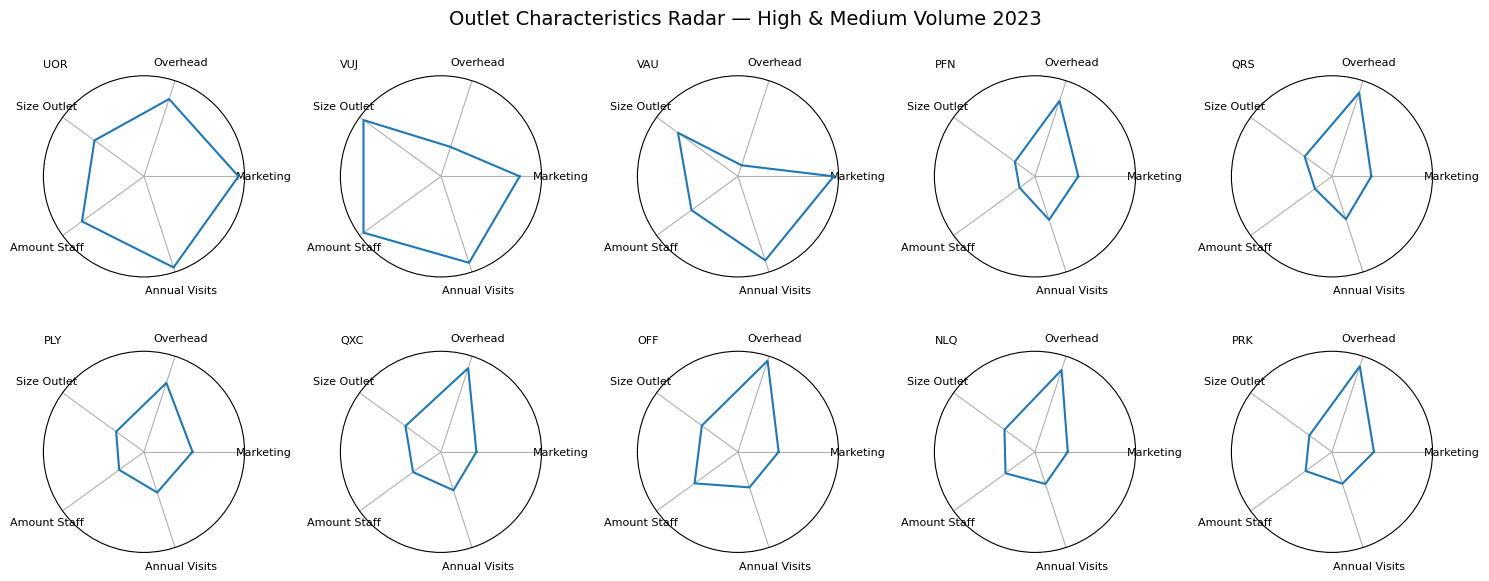

In [ ]:
summary_data = pd.DataFrame(index=data.columns)
summary_data['Marketing'] = outlet_marketing.loc[data.columns].values
summary_data['Overhead'] = outlet_overhead.loc[data.columns].values
summary_data['Size Outlet'] = outlet_size.loc[data.columns].values
summary_data['Amount Staff'] = outlet_staff.loc[data.columns].values
summary_data['Annual Visits'] = data.sum().values

print(summary_data.head())
print(summary_data.describe())

normalised_data = summary_data / summary_data.max()
print(normalised_data.head())

selected = ['UOR', 'VUJ', 'VAU', 'PFN', 'QRS', 'PLY', 'QXC', 'OFF', 'NLQ', 'PRK']

n_attributes = len(summary_data.columns)
angles = [n / float(n_attributes) * 2 * np.pi for n in range(n_attributes + 1)]

plt.figure(figsize=(15, 6))
plt.suptitle('Outlet Characteristics Radar — High & Medium Volume 2023', fontsize=14)

counter = 1
for name in selected:
    values = normalised_data.loc[[name]].values.flatten().tolist()
    values += values[:1]
    sub = plt.subplot(2, 5, counter, polar=True)
    sub.plot(angles, values)
    sub.set_ylim(ymax=1.05)
    sub.set_yticks([])
    sub.set_xticks(angles[0:-1])
    sub.set_xticklabels(normalised_data.columns, fontsize=8)
    sub.set_title(name, fontsize=8, loc='left')
    counter += 1

plt.tight_layout()
plt.show()

Figure 8: L07 Interactive - Interactive Bubble Chart

In [ ]:
!pip install hvplot

import hvplot.pandas
import holoviews as hv

def get_segment(v):
    if v >= 500_000: return 'High'
    elif v >= 200_000: return 'Medium'
    elif v >= 10_000: return 'Low'
    else: return 'Very Low'

summary_data = pd.DataFrame(index=data.columns)
summary_data['Marketing'] = outlet_marketing.loc[data.columns].values
summary_data['Overhead'] = outlet_overhead.loc[data.columns].values
summary_data['Size Outlet'] = outlet_size.loc[data.columns].values
summary_data['Amount Staff'] = outlet_staff.loc[data.columns].values
summary_data['Annual Visits'] = data.sum().values
summary_data['Segment'] = [get_segment(v) for v in summary_data['Annual Visits']]
summary_data['Outlet'] = summary_data.index

print(summary_data.head())

plot1 = summary_data.hvplot.scatter(
    frame_height=300, frame_width=300,
    x='Marketing', y='Annual Visits',
    by='Segment',
    size='Size Outlet',
    title='Marketing vs Visits',
    xlabel='Marketing Spend (£)',
    ylabel='Annual Visits',
    hover_cols=['Outlet', 'Amount Staff', 'Overhead', 'Size Outlet']
)

plot2 = summary_data.hvplot.scatter(
    frame_height=300, frame_width=300,
    x='Overhead', y='Annual Visits',
    by='Segment',
    size='Size Outlet',
    title='Overhead vs Visits',
    xlabel='Overhead Cost (£)',
    ylabel='Annual Visits',
    hover_cols=['Outlet', 'Amount Staff', 'Marketing', 'Size Outlet']
)

plot3 = summary_data.hvplot.scatter(
    frame_height=300, frame_width=300,
    x='Amount Staff', y='Annual Visits',
    by='Segment',
    size='Size Outlet',
    title='Staff vs Visits',
    xlabel='Number of Staff',
    ylabel='Annual Visits',
    hover_cols=['Outlet', 'Marketing', 'Overhead', 'Size Outlet']
)

plot4 = summary_data.hvplot.scatter(
    frame_height=300, frame_width=300,
    x='Size Outlet', y='Annual Visits',
    by='Segment',
    size='Size Outlet',
    title='Size vs Visits',
    xlabel='Outlet Size (m2)',
    ylabel='Annual Visits',
    hover_cols=['Outlet', 'Amount Staff', 'Overhead', 'Marketing']
)

plot = (plot1 + plot2 + plot3 + plot4).cols(2)
hv.extension('bokeh')
plot

     Marketing  Overhead  Size Outlet  Amount Staff  Annual Visits Segment  \
LRT       2000     66000           97             1          18166     Low   
QXC      27000     91000         2594            18         317718  Medium   
YRY       3000     79000          166             2          29721     Low   
SRZ       3000     77000          221             2          32799     Low   
NLQ      25000     89000         2227            19         265423  Medium   

    Outlet  
LRT    LRT  
QXC    QXC  
YRY    YRY  
SRZ    SRZ  
NLQ    NLQ  


:Layout
   .NdOverlay.I   :NdOverlay   [Segment]
      :Scatter   [Marketing]   (Annual Visits,Size Outlet,Outlet,Amount Staff,Overhead)
   .NdOverlay.II  :NdOverlay   [Segment]
      :Scatter   [Overhead]   (Annual Visits,Size Outlet,Outlet,Amount Staff,Marketing)
   .NdOverlay.III :NdOverlay   [Segment]
      :Scatter   [Amount Staff]   (Annual Visits,Size Outlet,Outlet,Marketing,Overhead)
   .NdOverlay.IV  :NdOverlay   [Segment]
      :Scatter   [Size Outlet]   (Annual Visits,Outlet,Amount Staff,Overhead,Marketing)

##Markdown Figure 8: Interactive Bubble Chart-User Guide:

This visualisation contains four interactive scatter plots arranged in a 2×2 grid. Each panel plots a different business characteristic (marketing spend, overhead costs, number of staff and outlet size) against annual visits for all 45 ChrisCo outlets.
Bubble colour indicates volume segment (green: high, orange: medium, blue: low, yellow: very low). Bubble size indicates outlet floor space in m² — larger bubbles indicate bigger outlets.
Each panel can be interacted with independently using the Bokeh toolbar displayed to the right of each chart.

###!!!!!!Please open this file through Google Colab! The interactivity is applied on the Google Colab notebook and would need changes to open through a different portal.!!!!!

###Interactive Instructions:

Hover over a bubble:

* Move your mouse over any bubble in any panel. A tooltip will appear showing the outlet name, annual visits and the key business characteristics relevant to that panel.
* Example: hovering over the Overhead panel reveals the exact overhead cost and annual visit count for that outlet.
* This is the primary way to identify individual outlets without cluttering up the chart with labels.

Zoom:
* Scroll up with your mouse wheel over any panel to zoom in.
* Alternatively, use the box zoom tool to draw a selection area.
* This is most useful in the bottom-left corner, where outlets with low and very low volumes cluster closely together.

Pan:
* Click the pan icon and drag within any panel.
* Use this feature after zooming to explore different areas of the chart.

Reset:
* Click the Reset icon on any panel's toolbar.
* This returns that panel to its original full view.



###Suggested Exploration:
1. Overhead vs. visits panel: Hover over the orange (medium-volume) bubbles that sit unusually high on the overhead axis. These are the outlets that are paying high operational costs without receiving a proportionate number of visitors in return. Note the outlet names that appear. These are ChrisCo's cost-efficiency priorities.
2. Staff vs Visits panel: Hover over the three green (high-volume) bubbles in the top-right corner. Confirm the staffing levels of UOR, VUJ and VAU (all of which are between 40 and 50 staff). Then hover over the medium-volume orange bubbles to compare their staffing levels.
3. Marketing vs. Visits Panel: Zoom into the bottom-left cluster and hover over the individual blue and yellow bubbles. Identify the low-volume outlets that are spending the most on marketing relative to the number of visits they receive.
4. Size vs. visits panel: Look for large bubbles that sit low on the visits axis. A large bubble in this position indicates an outlet with significant floor space that is underperforming in terms of customer footfall.
5. Compare across all four panels: Select a medium-volume outlet of interest from the Overhead panel and locate the same bubble in the other three panels.This builds a complete investment profile. Does that outlet also overspend on marketing? Is it large but underperforming? Is it understaffed relative to its peers?



-----------------------------------------------------



-----------------------------------------------------------------------------------------------------


Appendix: Further visualisations (not included in the report and 8 graphs)

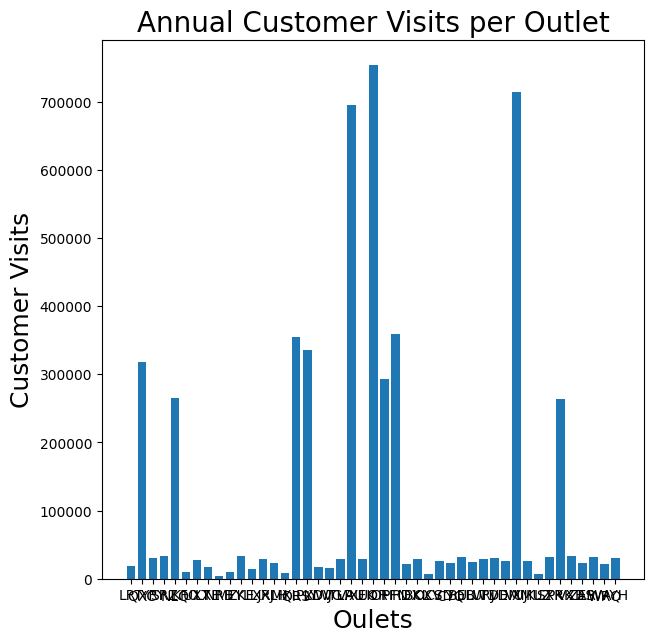

In [ ]:
plt.figure(figsize=(7, 7))
x_pos = np.arange(len(data.columns))
plt.bar(x_pos, data.sum(), align='center')
plt.xticks(x_pos, data.columns)
plt.xlabel('Oulets', fontsize=18)
plt.ylabel('Customer Visits', fontsize=18)
plt.title('Annual Customer Visits per Outlet', fontsize=20)
plt.show()


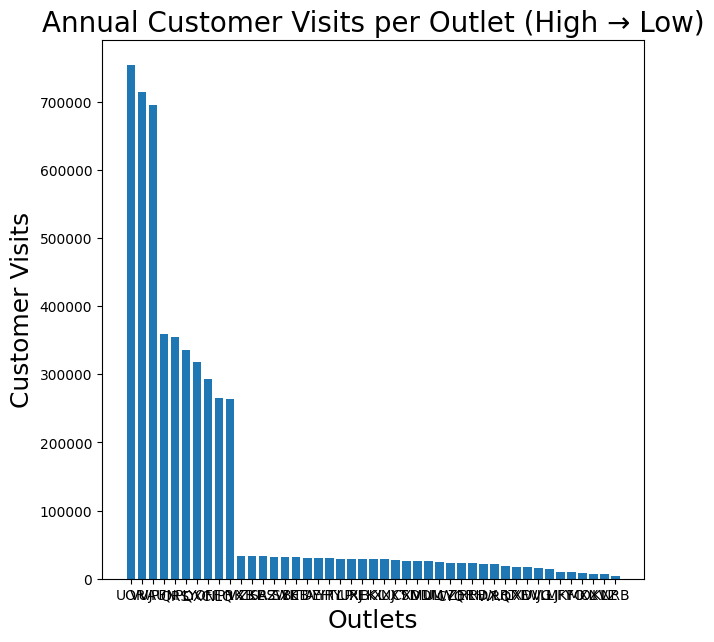

In [ ]:
total_visits = data.sum()
total_visits_sorted = total_visits.sort_values(ascending=False)
x_pos = np.arange(len(total_visits_sorted))


plt.figure(figsize=(7, 7))
plt.bar(x_pos, total_visits_sorted.values, align='center')
plt.xticks(x_pos, total_visits_sorted.index)
plt.xlabel('Outlets', fontsize=18)
plt.ylabel('Customer Visits', fontsize=18)
plt.title('Annual Customer Visits per Outlet (High → Low)', fontsize=20)

plt.show()

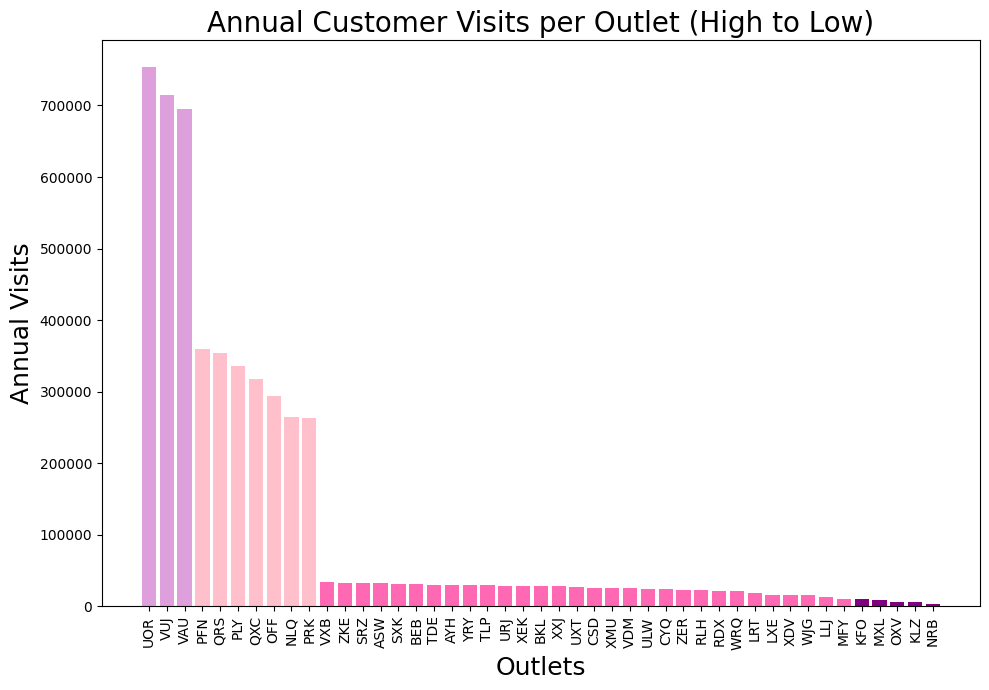

In [ ]:
total_visits = data.sum()
segment_limits = {
    0: 'Very Low',
    10_000: 'Low',
    200_000: 'Medium',
    500_000: 'High',
}

segment_colours = {
    'Very Low': 'purple',
    'Low': 'hotpink',
    'Medium': 'pink',
    'High': 'plum',
}


def get_segment(value):
    if value >= 500_000:
        return 'High'
    elif value >= 200_000:
        return 'Medium'
    elif value >= 10_000:
        return 'Low'
    else:
        return 'Very Low'

total_visits_sorted = total_visits.sort_values(ascending=False)
colours = [segment_colours[get_segment(value)] for value in total_visits_sorted]

plt.figure(figsize=(10, 7))
x_pos = np.arange(len(total_visits_sorted))
plt.bar(x_pos, total_visits_sorted.values, align='center', color=colours)
plt.xticks(x_pos, total_visits_sorted.index, rotation=90)
plt.xlabel('Outlets', fontsize=18)
plt.ylabel('Annual Visits', fontsize=18)
plt.title('Annual Customer Visits per Outlet (High to Low)', fontsize=20)
plt.tight_layout()
plt.show()

            LRT   QXC  YRY  SRZ  NLQ  KFO  UXT  LXE  NRB  MFY  ...   VUJ  XMU  \
Date                                                           ...              
2023-01-01   71  1150   82   91  789    0   59   74    0    0  ...  1870   58   
2023-01-02   89   937   88   74  684    0   82   46    0    0  ...  2067   67   
2023-01-03   49  1015   82  103  695    0   74   57    0    0  ...  2030   80   
2023-01-04   67   748   76   98  592    0   57   74    0    0  ...  1719   75   
2023-01-05   71   685   65   63  483    0   80   54    0    0  ...  1442   76   

            KLZ  SXK  PRK  VXB  ZER  ASW  WRQ  AYH  
Date                                                
2023-01-01   73   88  857   64   62   79   51   65  
2023-01-02   72   77  807   78   67   88   58   97  
2023-01-03   59   87  712   97   57   77   67   71  
2023-01-04   84   80  581  114   56   82   63   94  
2023-01-05   85  103  682   97   71   82   58  105  

[5 rows x 45 columns]


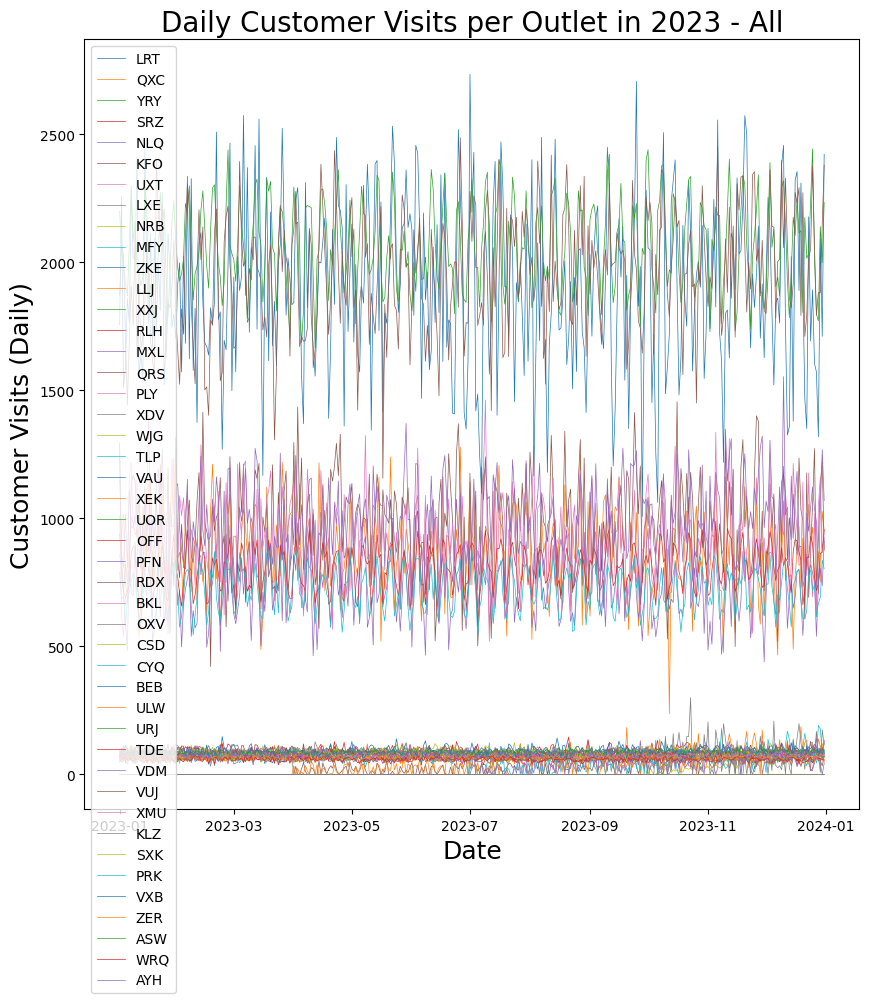

In [ ]:
data.index = pd.to_datetime(data.index)
print(data.head())
# data.plot.line(linewidth=0.5, figsize=(7, 7))
plt.figure(figsize=(10, 10))
plt.plot(data, linewidth=0.5)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Customer Visits (Daily)', fontsize=18)
plt.title('Daily Customer Visits per Outlet in 2023 - All', fontsize=20)
plt.legend(data.columns, loc=2)
plt.show()

            LRT   QXC  YRY  SRZ  NLQ  KFO  UXT  LXE  NRB  MFY  ...   VUJ  XMU  \
Date                                                           ...              
2023-01-01   71  1150   82   91  789    0   59   74    0    0  ...  1870   58   
2023-01-02   89   937   88   74  684    0   82   46    0    0  ...  2067   67   
2023-01-03   49  1015   82  103  695    0   74   57    0    0  ...  2030   80   
2023-01-04   67   748   76   98  592    0   57   74    0    0  ...  1719   75   
2023-01-05   71   685   65   63  483    0   80   54    0    0  ...  1442   76   

            KLZ  SXK  PRK  VXB  ZER  ASW  WRQ  AYH  
Date                                                
2023-01-01   73   88  857   64   62   79   51   65  
2023-01-02   72   77  807   78   67   88   58   97  
2023-01-03   59   87  712   97   57   77   67   71  
2023-01-04   84   80  581  114   56   82   63   94  
2023-01-05   85  103  682   97   71   82   58  105  

[5 rows x 45 columns]


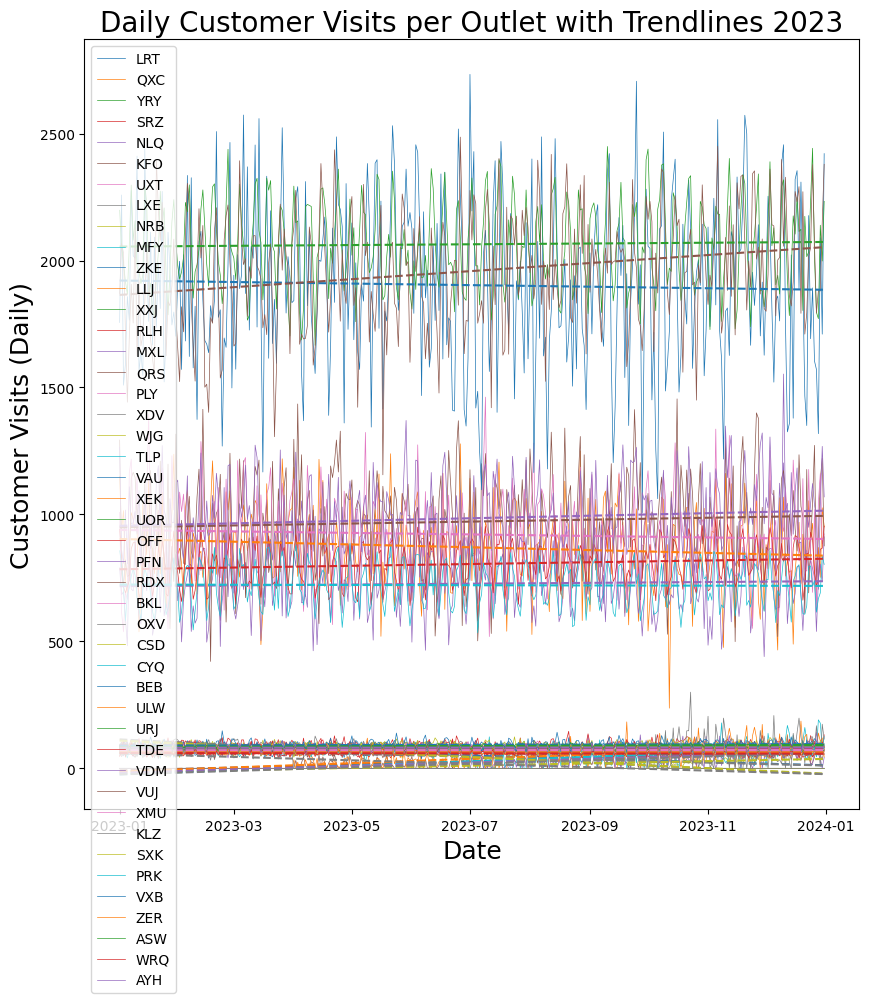

In [ ]:
data.index = pd.to_datetime(data.index)
print(data.head())

plt.figure(figsize=(10, 10))
plt.plot(data, linewidth=0.5)
plt.gca().set_prop_cycle(None)
for name in data.columns:
    x = np.arange(len(data[name]))
    z = np.polyfit(x, data[name], 1)
    trend = np.poly1d(z)
    plt.plot(data.index, trend(x), linestyle='--')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Customer Visits (Daily)', fontsize=18)
plt.title('Daily Customer Visits per Outlet with Trendlines 2023', fontsize=20)
plt.legend(data.columns, loc=2)
plt.show()

            LRT   QXC  YRY  SRZ  NLQ  KFO  UXT  LXE  NRB  MFY  ...   VUJ  XMU  \
Date                                                           ...              
2023-01-01   71  1150   82   91  789    0   59   74    0    0  ...  1870   58   
2023-01-02   89   937   88   74  684    0   82   46    0    0  ...  2067   67   
2023-01-03   49  1015   82  103  695    0   74   57    0    0  ...  2030   80   
2023-01-04   67   748   76   98  592    0   57   74    0    0  ...  1719   75   
2023-01-05   71   685   65   63  483    0   80   54    0    0  ...  1442   76   

            KLZ  SXK  PRK  VXB  ZER  ASW  WRQ  AYH  
Date                                                
2023-01-01   73   88  857   64   62   79   51   65  
2023-01-02   72   77  807   78   67   88   58   97  
2023-01-03   59   87  712   97   57   77   67   71  
2023-01-04   84   80  581  114   56   82   63   94  
2023-01-05   85  103  682   97   71   82   58  105  

[5 rows x 45 columns]
            LRT  QXC  YRY  SRZ  NLQ  K

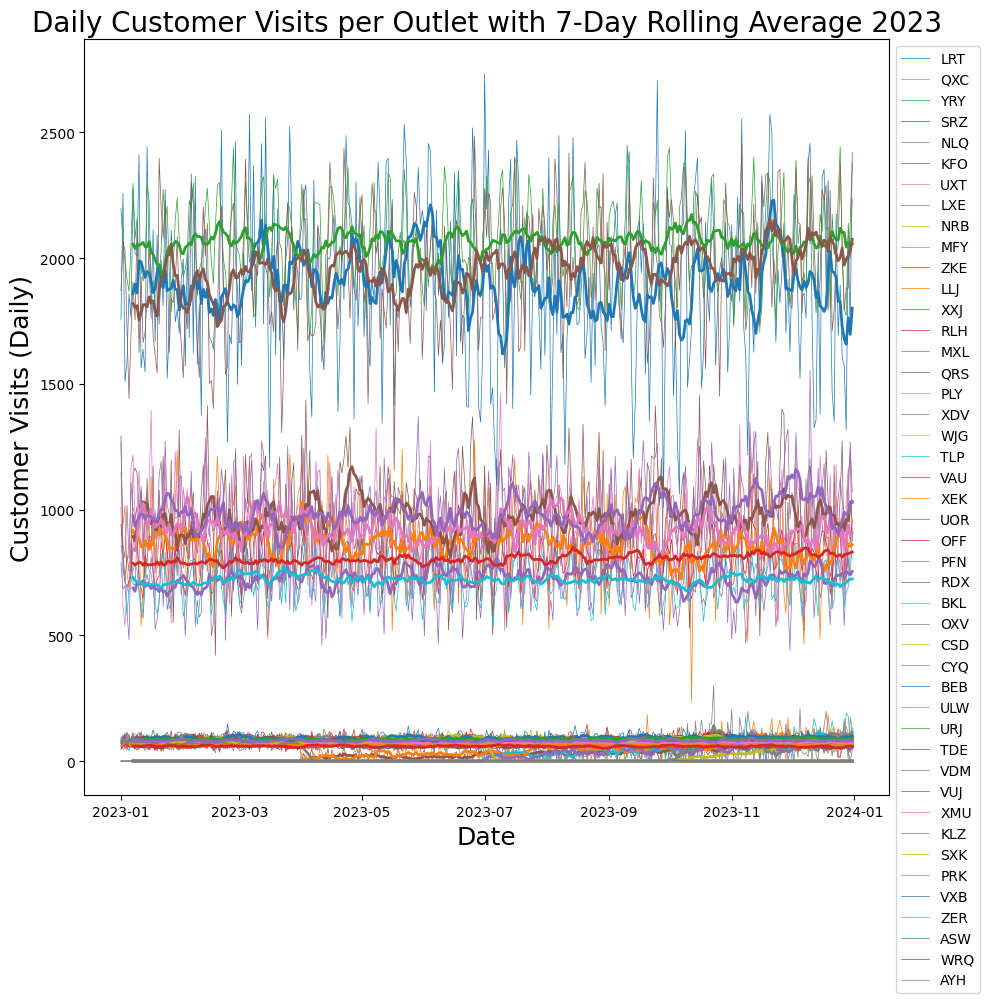

In [ ]:
data.index = pd.to_datetime(data.index)
print(data.head())

averaged_data = data.rolling(window=7).mean()
print(averaged_data.head())

plt.figure(figsize=(10, 10))
plt.plot(data, linewidth=0.5)
plt.gca().set_prop_cycle(None)
plt.plot(averaged_data, linewidth=2)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Customer Visits (Daily)', fontsize=18)
plt.title('Daily Customer Visits per Outlet with 7-Day Rolling Average 2023', fontsize=20)
plt.legend(data.columns, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

     Marketing  Overhead  Size Outlet  Amount Staff  Annual Visits
LRT       2000     66000           97             1          18166
QXC      27000     91000         2594            18         317718
YRY       3000     79000          166             2          29721
SRZ       3000     77000          221             2          32799
NLQ      25000     89000         2227            19         265423
          Marketing      Overhead  Size Outlet  Amount Staff  Annual Visits
count     45.000000     45.000000    45.000000     45.000000      45.000000
mean   11377.777778  66155.555556   740.311111      6.600000  114480.133333
std    18618.525585  27287.988996  1280.318902     11.068793  195814.676557
min     1000.000000  12000.000000    25.000000      1.000000    3897.000000
25%     2000.000000  39000.000000    97.000000      1.000000   21543.000000
50%     3000.000000  79000.000000   183.000000      2.000000   28695.000000
75%     4000.000000  89000.000000   285.000000      3.000000   328

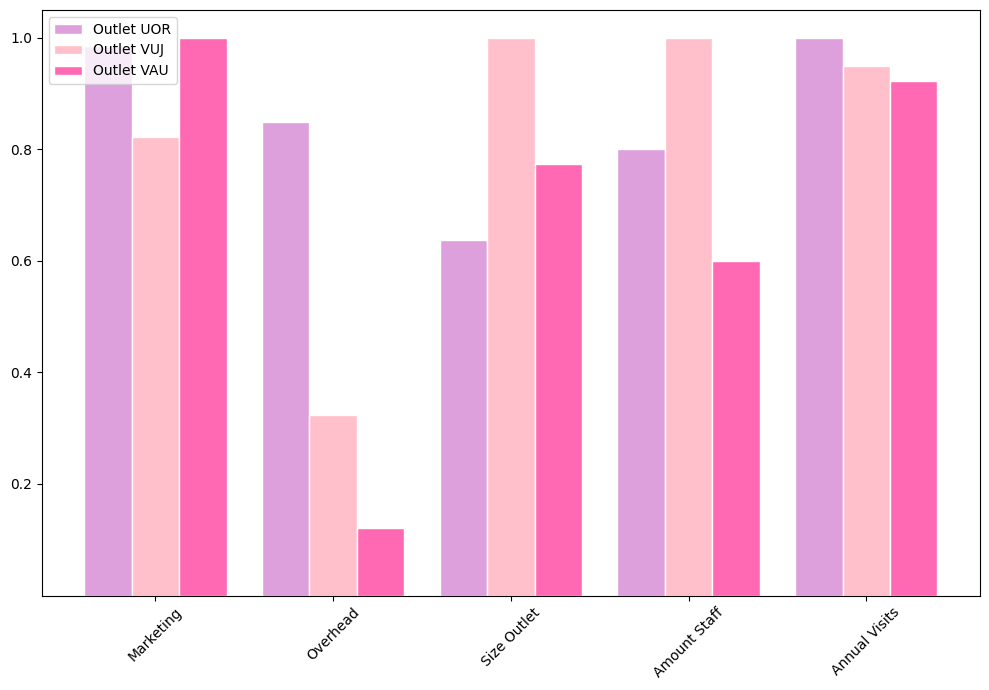

In [ ]:
summary_data = pd.DataFrame(index=data.columns)
summary_data['Marketing'] = outlet_marketing.values
summary_data['Overhead'] = outlet_overhead.values
summary_data['Size Outlet'] = outlet_size.values
summary_data['Amount Staff'] = outlet_staff.values
summary_data['Annual Visits'] = data.sum().values

print(summary_data.head())
print(summary_data.describe())

normalised_data = summary_data / summary_data.max()
print(normalised_data.head())

selected = ['UOR', 'VUJ', 'VAU']
colours = ['plum', 'pink', 'hotpink']

plt.figure(figsize=(10, 7))
c = 0
n_bars = len(selected)
x_pos_base = np.arange(len(summary_data.columns))
bar_width = 0.8 / n_bars

for name in selected:
    values = normalised_data.loc[[name]].values.flatten().tolist()
    x_pos = [x + (bar_width * c) for x in x_pos_base]
    plt.bar(x_pos, values,
            color=colours[c % len(colours)],
            width=bar_width,
            edgecolor='white',
            label='Outlet ' + name)
    c += 1

plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0])
x_pos = [x + (bar_width * (c - 1) / 2) for x in x_pos_base]
plt.xticks(x_pos, summary_data.columns, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

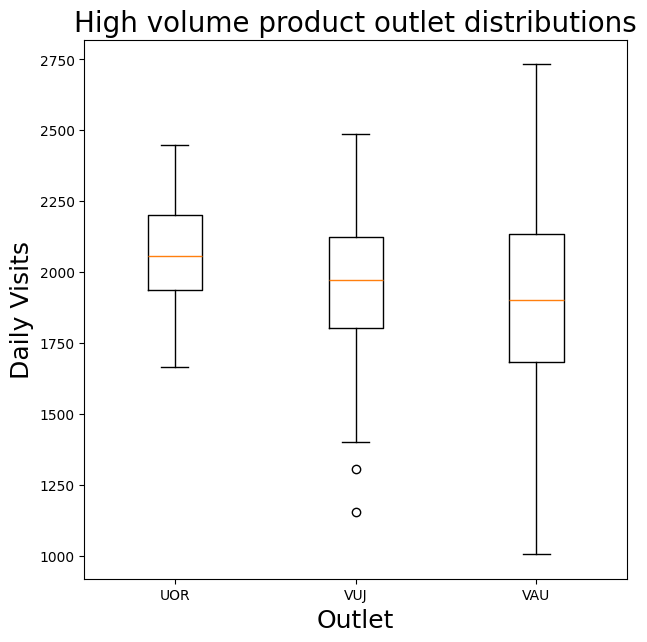

In [ ]:

selected = ['UOR', 'VUJ', 'VAU']

plt.figure(figsize=(7, 7))
# data[selected].boxplot()
plt.boxplot(data[selected], tick_labels=selected)
plt.xlabel('Outlet', fontsize=18)
plt.ylabel('Daily Visits', fontsize=18)
plt.title('High volume product outlet distributions', fontsize=20)
plt.show()


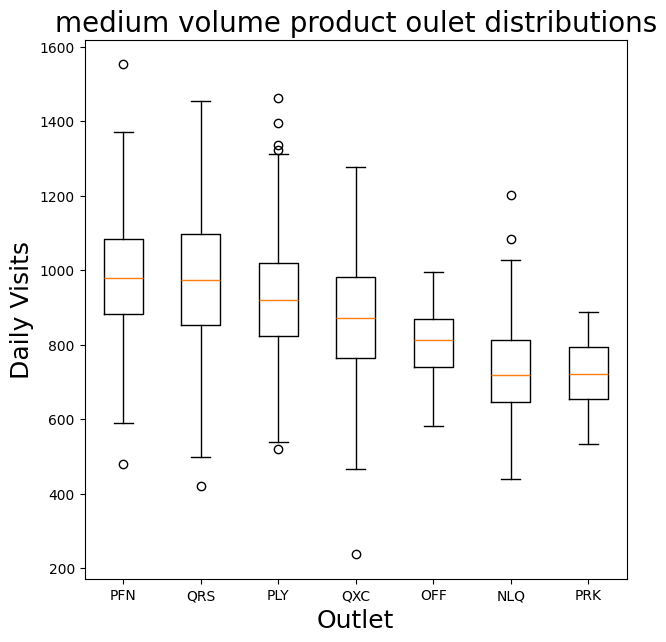

In [ ]:
selected = ['PFN', 'QRS', 'PLY', 'QXC', 'OFF', 'NLQ', 'PRK']

plt.figure(figsize=(7, 7))
# data[selected].boxplot()
plt.boxplot(data[selected], tick_labels=selected)
plt.xlabel('Outlet', fontsize=18)
plt.ylabel('Daily Visits', fontsize=18)
plt.title('medium volume product oulet distributions', fontsize=20)
plt.show()


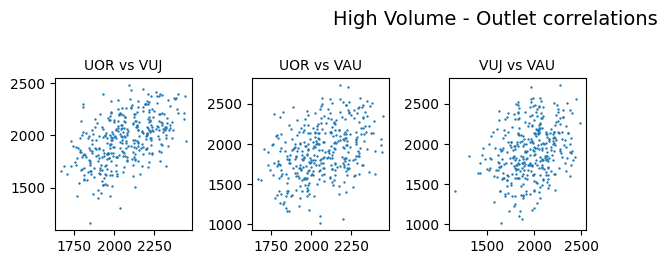

In [ ]:
selected = ['UOR', 'VUJ', 'VAU']

counter = 1
fig = plt.figure(figsize=(10, 10))
fig.suptitle('High Volume - Outlet correlations', fontsize=14, position=(0.5, 1.0))

for i, name_i in enumerate(selected):
    for j in range(i + 1, len(selected)):
        name_j = selected[j]
        sub = fig.add_subplot(5, 5, counter)
        sub.set_title(name_i + ' vs ' + name_j, fontsize=10)
        sub.scatter(data[name_i], data[name_j], s=0.5)
        counter += 1

plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.tight_layout()
plt.show()

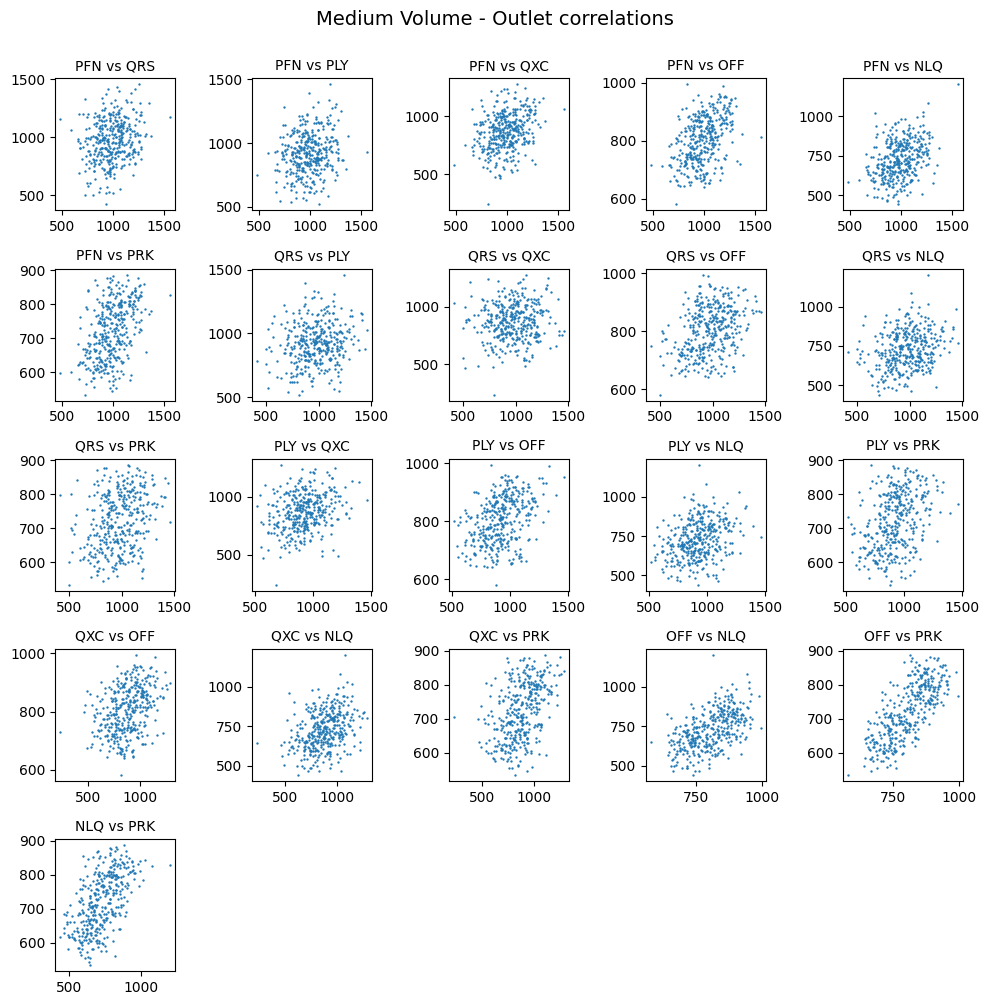

In [ ]:
selected = ['PFN', 'QRS', 'PLY', 'QXC', 'OFF', 'NLQ', 'PRK']

counter = 1
fig = plt.figure(figsize=(10, 10))
fig.suptitle('Medium Volume - Outlet correlations', fontsize=14, position=(0.5, 1.0))

for i, name_i in enumerate(selected):
    for j in range(i + 1, len(selected)):
        name_j = selected[j]
        sub = fig.add_subplot(5, 5, counter)
        sub.set_title(name_i + ' vs ' + name_j, fontsize=10)
        sub.scatter(data[name_i], data[name_j], s=0.5)
        counter += 1

plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.tight_layout()
plt.show()

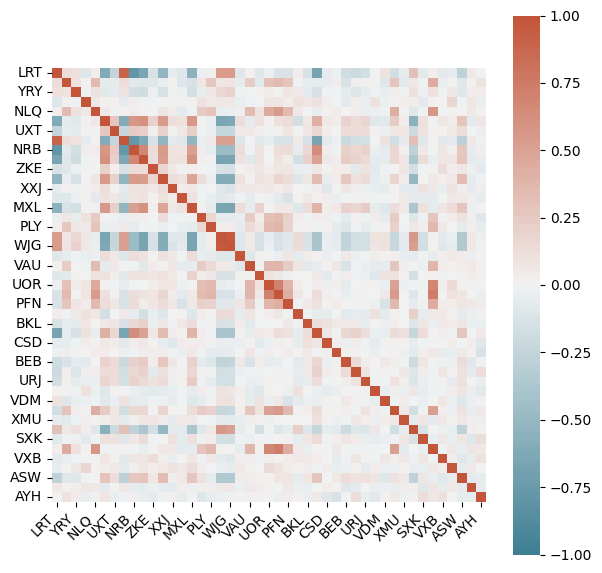

In [ ]:
plt.figure(figsize=(7, 7))
corr = data.corr()
ax = sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(220, 20, n=200), square=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
plt.show()


In [ ]:
!pip install hvplot

import hvplot.pandas
import holoviews as hv

def get_segment(v):
    if v >= 500_000: return 'High'
    elif v >= 200_000: return 'Medium'
    elif v >= 10_000: return 'Low'
    else: return 'Very Low'

summary_data = pd.DataFrame(index=data.columns)
summary_data['Marketing'] = outlet_marketing.loc[data.columns].values
summary_data['Overhead'] = outlet_overhead.loc[data.columns].values
summary_data['Size Outlet'] = outlet_size.loc[data.columns].values
summary_data['Amount Staff'] = outlet_staff.loc[data.columns].values
summary_data['Annual Visits'] = data.sum().values
summary_data['Segment'] = [get_segment(v) for v in summary_data['Annual Visits']]

print(summary_data.head())

max_marketing = summary_data['Marketing'].max()

plot1 = summary_data.hvplot.scatter(
    frame_height=500, frame_width=600,
    x='Marketing', y='Annual Visits',
    by='Segment',
    size='Size Outlet',
    title='Marketing Spend vs Annual Visits 2023 (bubble = outlet size)',
    xlabel='Annual Marketing Spend (£)',
    ylabel='Annual Customer Visits',
    hover_cols=['Amount Staff', 'Overhead', 'Size Outlet']
)

line_high = hv.Curve([(0, 0), (max_marketing, max_marketing * 50)],
                      label='50 visits per £') \
    .opts(line_dash='dashed', line_width=0.5, color='black')

line_mid = hv.Curve([(0, 0), (max_marketing, max_marketing * 25)],
                     label='25 visits per £') \
    .opts(line_dash='dashed', line_width=0.5, color='red')

line_low = hv.Curve([(0, 0), (max_marketing, max_marketing * 10)],
                     label='10 visits per £') \
    .opts(line_dash='dashed', line_width=0.5, color='orange')

plot = plot1 * line_high * line_mid * line_low

hv.extension('bokeh')
plot

     Marketing  Overhead  Size Outlet  Amount Staff  Annual Visits Segment
LRT       2000     66000           97             1          18166     Low
QXC      27000     91000         2594            18         317718  Medium
YRY       3000     79000          166             2          29721     Low
SRZ       3000     77000          221             2          32799     Low
NLQ      25000     89000         2227            19         265423  Medium


:Overlay
   .NdOverlay.I                 :NdOverlay   [Segment]
      :Scatter   [Marketing]   (Annual Visits,Size Outlet,Amount Staff,Overhead)
   .Curve.A_50_visits_per_pound :Curve   [x]   (y)
   .Curve.A_25_visits_per_pound :Curve   [x]   (y)
   .Curve.A_10_visits_per_pound :Curve   [x]   (y)

     Marketing  Overhead  Size Outlet  Amount Staff  Annual Visits  \
LRT       2000     66000           97             1          18166   
QXC      27000     91000         2594            18         317718   
YRY       3000     79000          166             2          29721   
SRZ       3000     77000          221             2          32799   
NLQ      25000     89000         2227            19         265423   

     Visits vs Marketing Costs  
LRT                      16166  
QXC                     290718  
YRY                      26721  
SRZ                      29799  
NLQ                     240423  
          Marketing      Overhead  Size Outlet  Amount Staff  Annual Visits  \
count     45.000000     45.000000    45.000000     45.000000      45.000000   
mean   11377.777778  66155.555556   740.311111      6.600000  114480.133333   
std    18618.525585  27287.988996  1280.318902     11.068793  195814.676557   
min     1000.000000  12000.000000    25.000000      1.000000    3

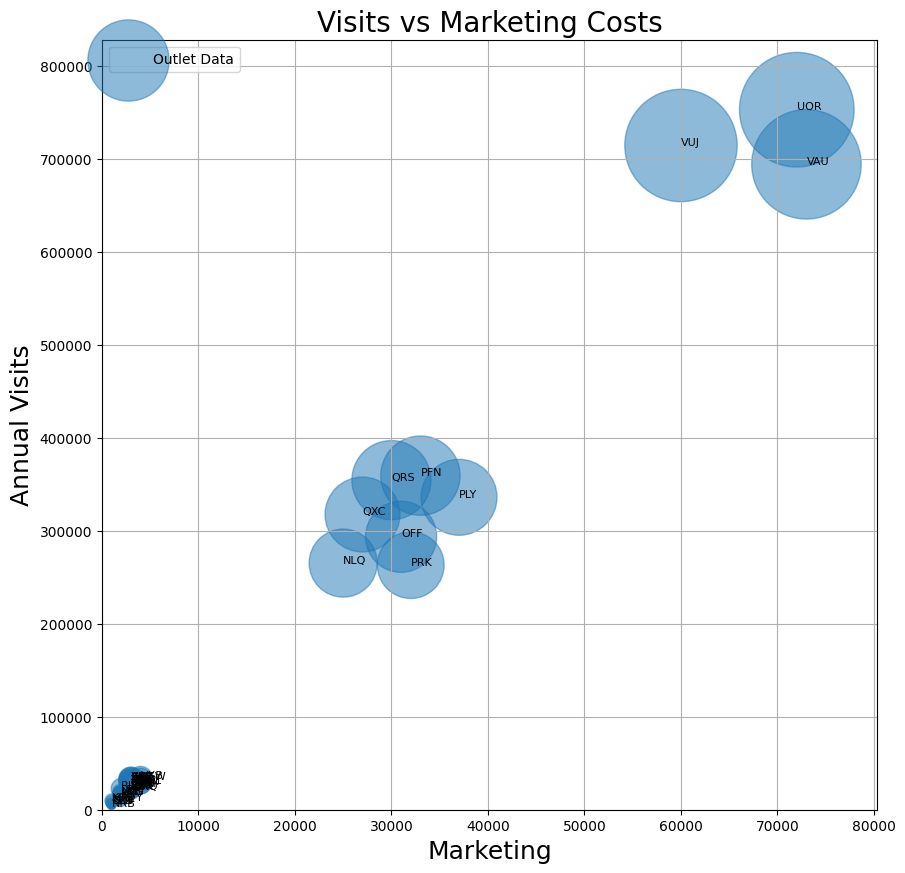

In [ ]:
summary_data = pd.DataFrame(index=data.columns)
summary_data['Marketing'] = outlet_marketing.values
summary_data['Overhead'] = outlet_overhead.values
summary_data['Size Outlet'] = outlet_size.values
summary_data['Amount Staff'] = outlet_staff.values
summary_data['Annual Visits'] = data.sum().values
summary_data['Visits vs Marketing Costs'] = summary_data['Annual Visits'] - summary_data['Marketing']
print(summary_data.head())
print(summary_data.describe())

summary_data['BubbleSize'] = summary_data['Visits vs Marketing Costs'].abs() / 100

plt.figure(figsize=(10, 10))
plt.scatter(summary_data['Marketing'], summary_data['Annual Visits'], s=summary_data['BubbleSize'], alpha=0.5)
plt.xlim(0, summary_data['Marketing'].max() * 1.1)
plt.ylim(0, summary_data['Annual Visits'].max() * 1.1)
plt.title('Visits vs Marketing Costs', fontsize=20)
plt.xlabel('Marketing', fontsize=18)
plt.ylabel('Annual Visits', fontsize=18)
plt.grid(True)

for i, name in enumerate(summary_data.index):
    plt.annotate(name, (summary_data['Marketing'].iloc[i], summary_data['Annual Visits'].iloc[i]), fontsize=8)

plt.legend(['Outlet Data'], loc='upper left')
plt.show()

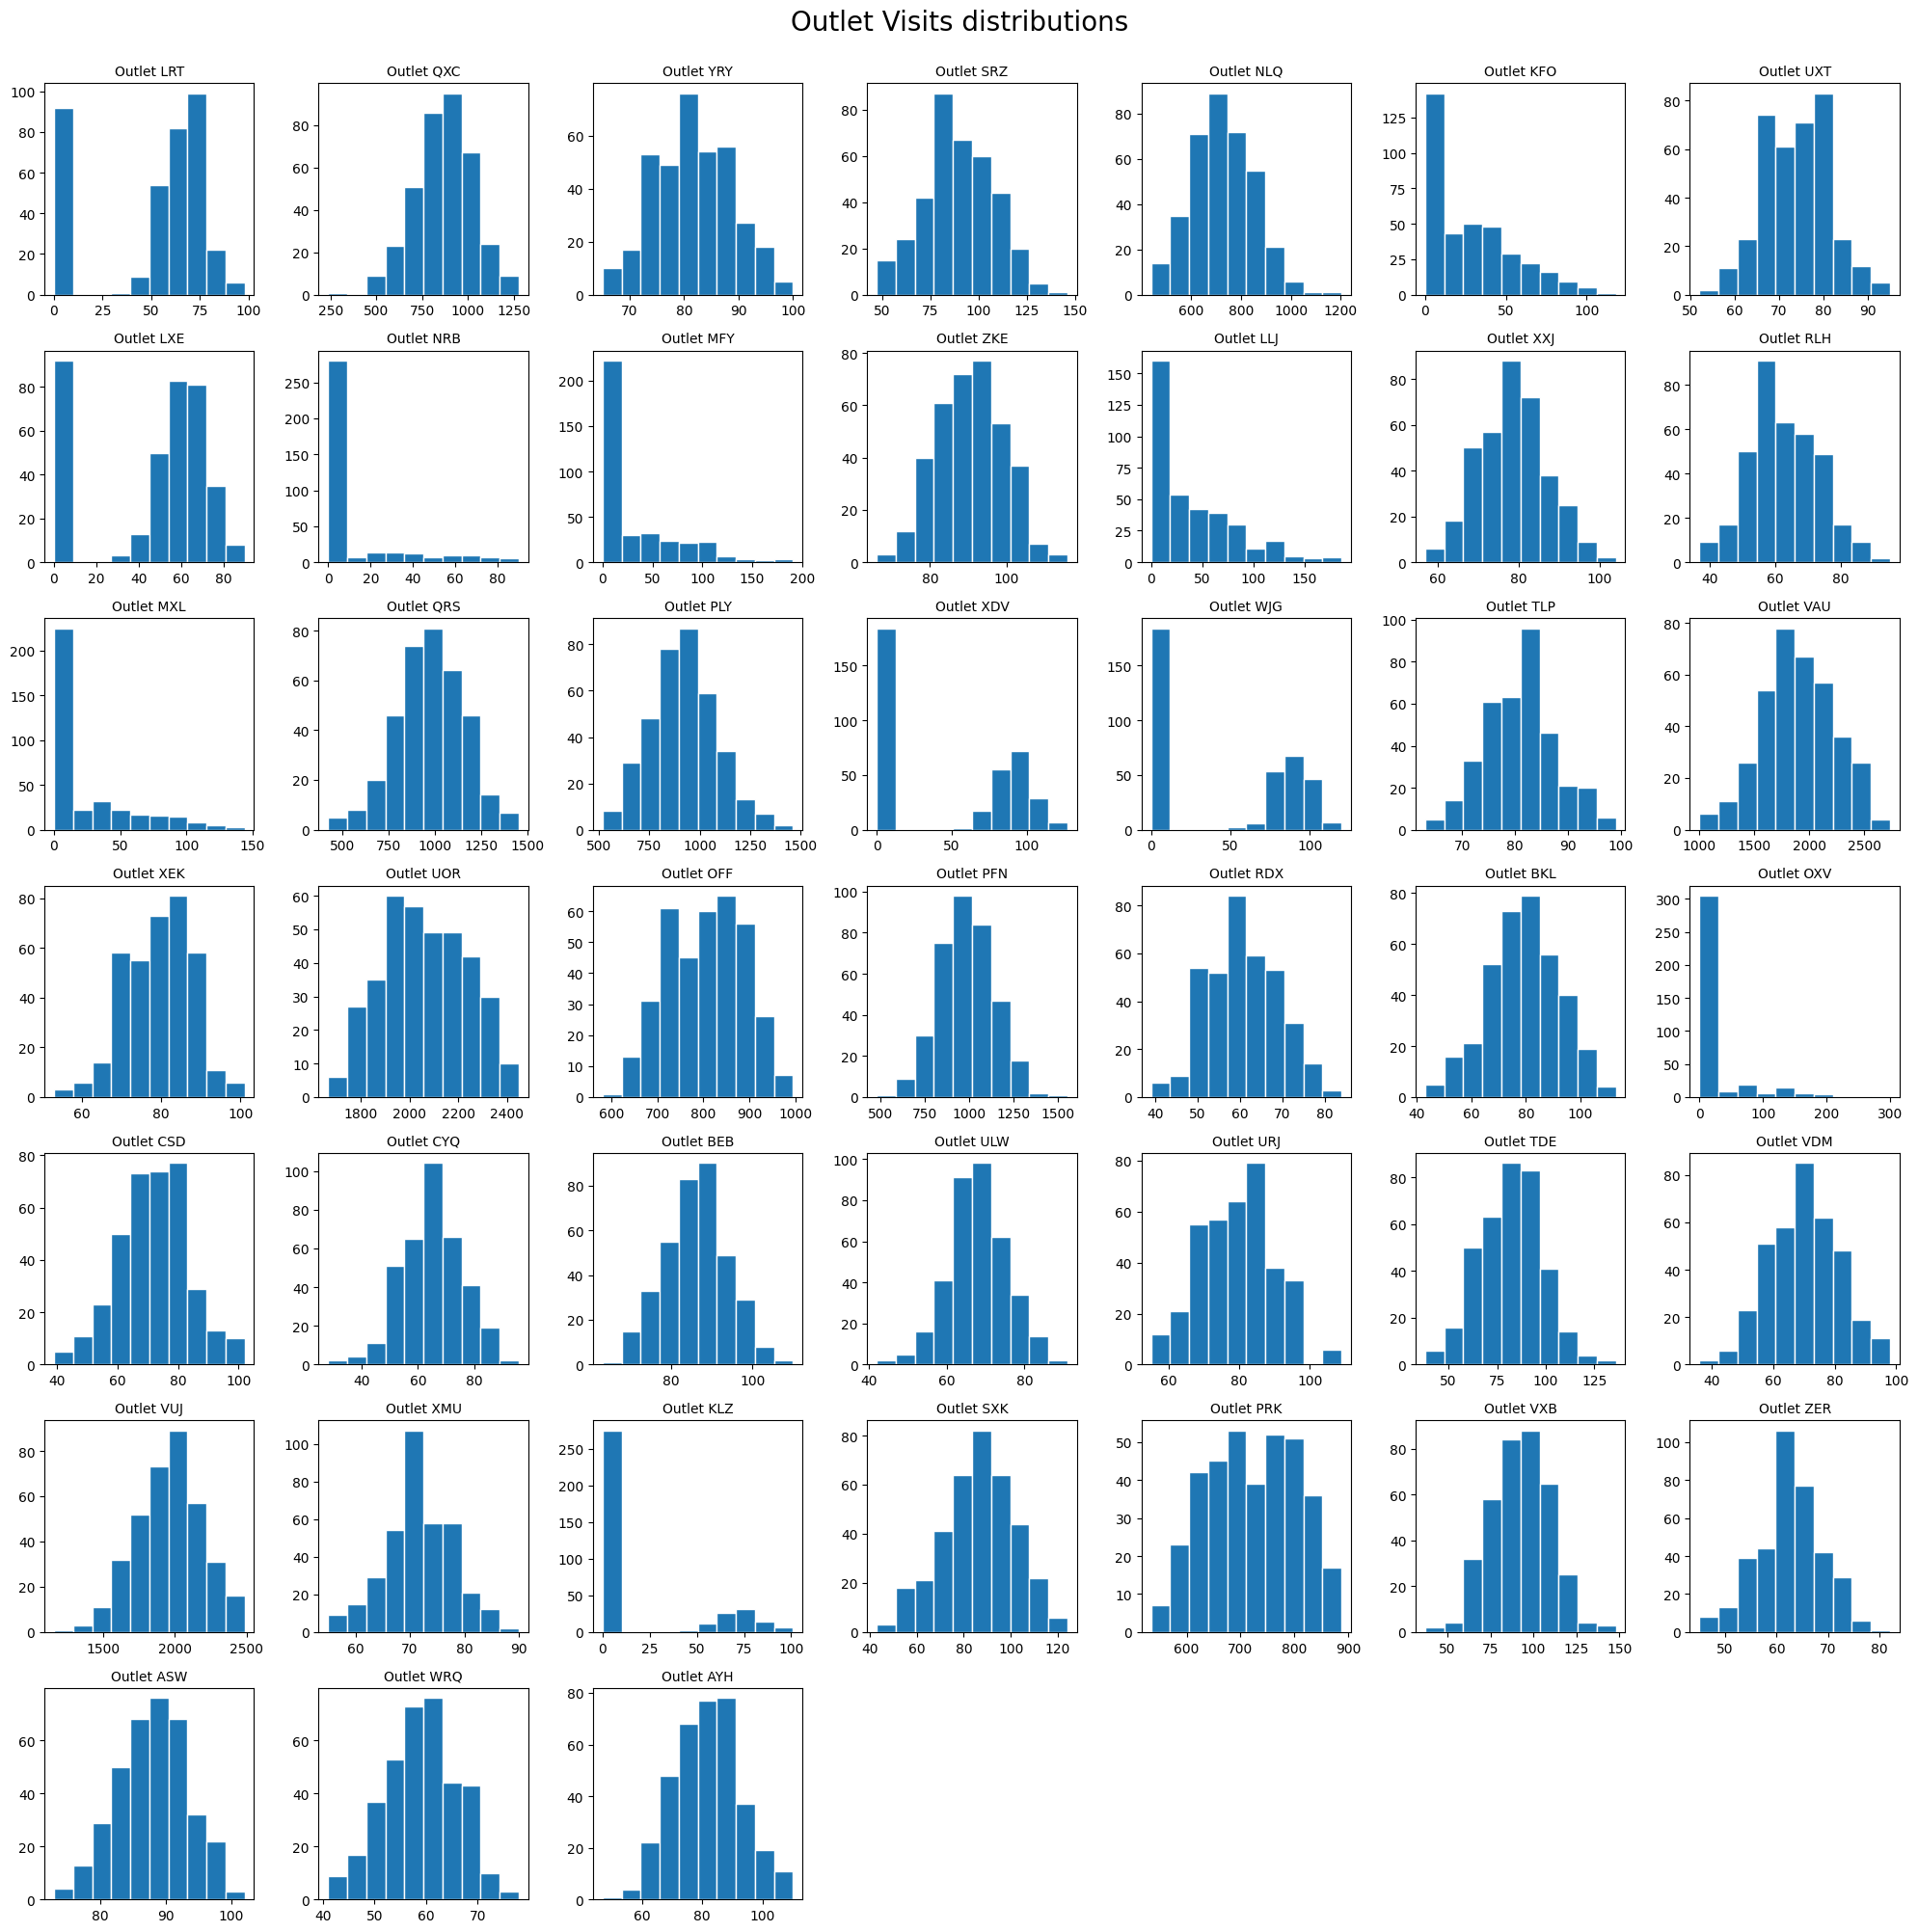

In [ ]:
counter = 1
fig = plt.figure(figsize=(20, 20))
fig.suptitle('Outlet Visits distributions', fontsize=20, position=(0.5, 1.0))
for name in data:
    sub = fig.add_subplot(7, 7, counter)
    sub.set_title('Outlet ' + name, fontsize=10)
    sub.hist(data[name], edgecolor='w')
    counter += 1
plt.tight_layout()
plt.show()

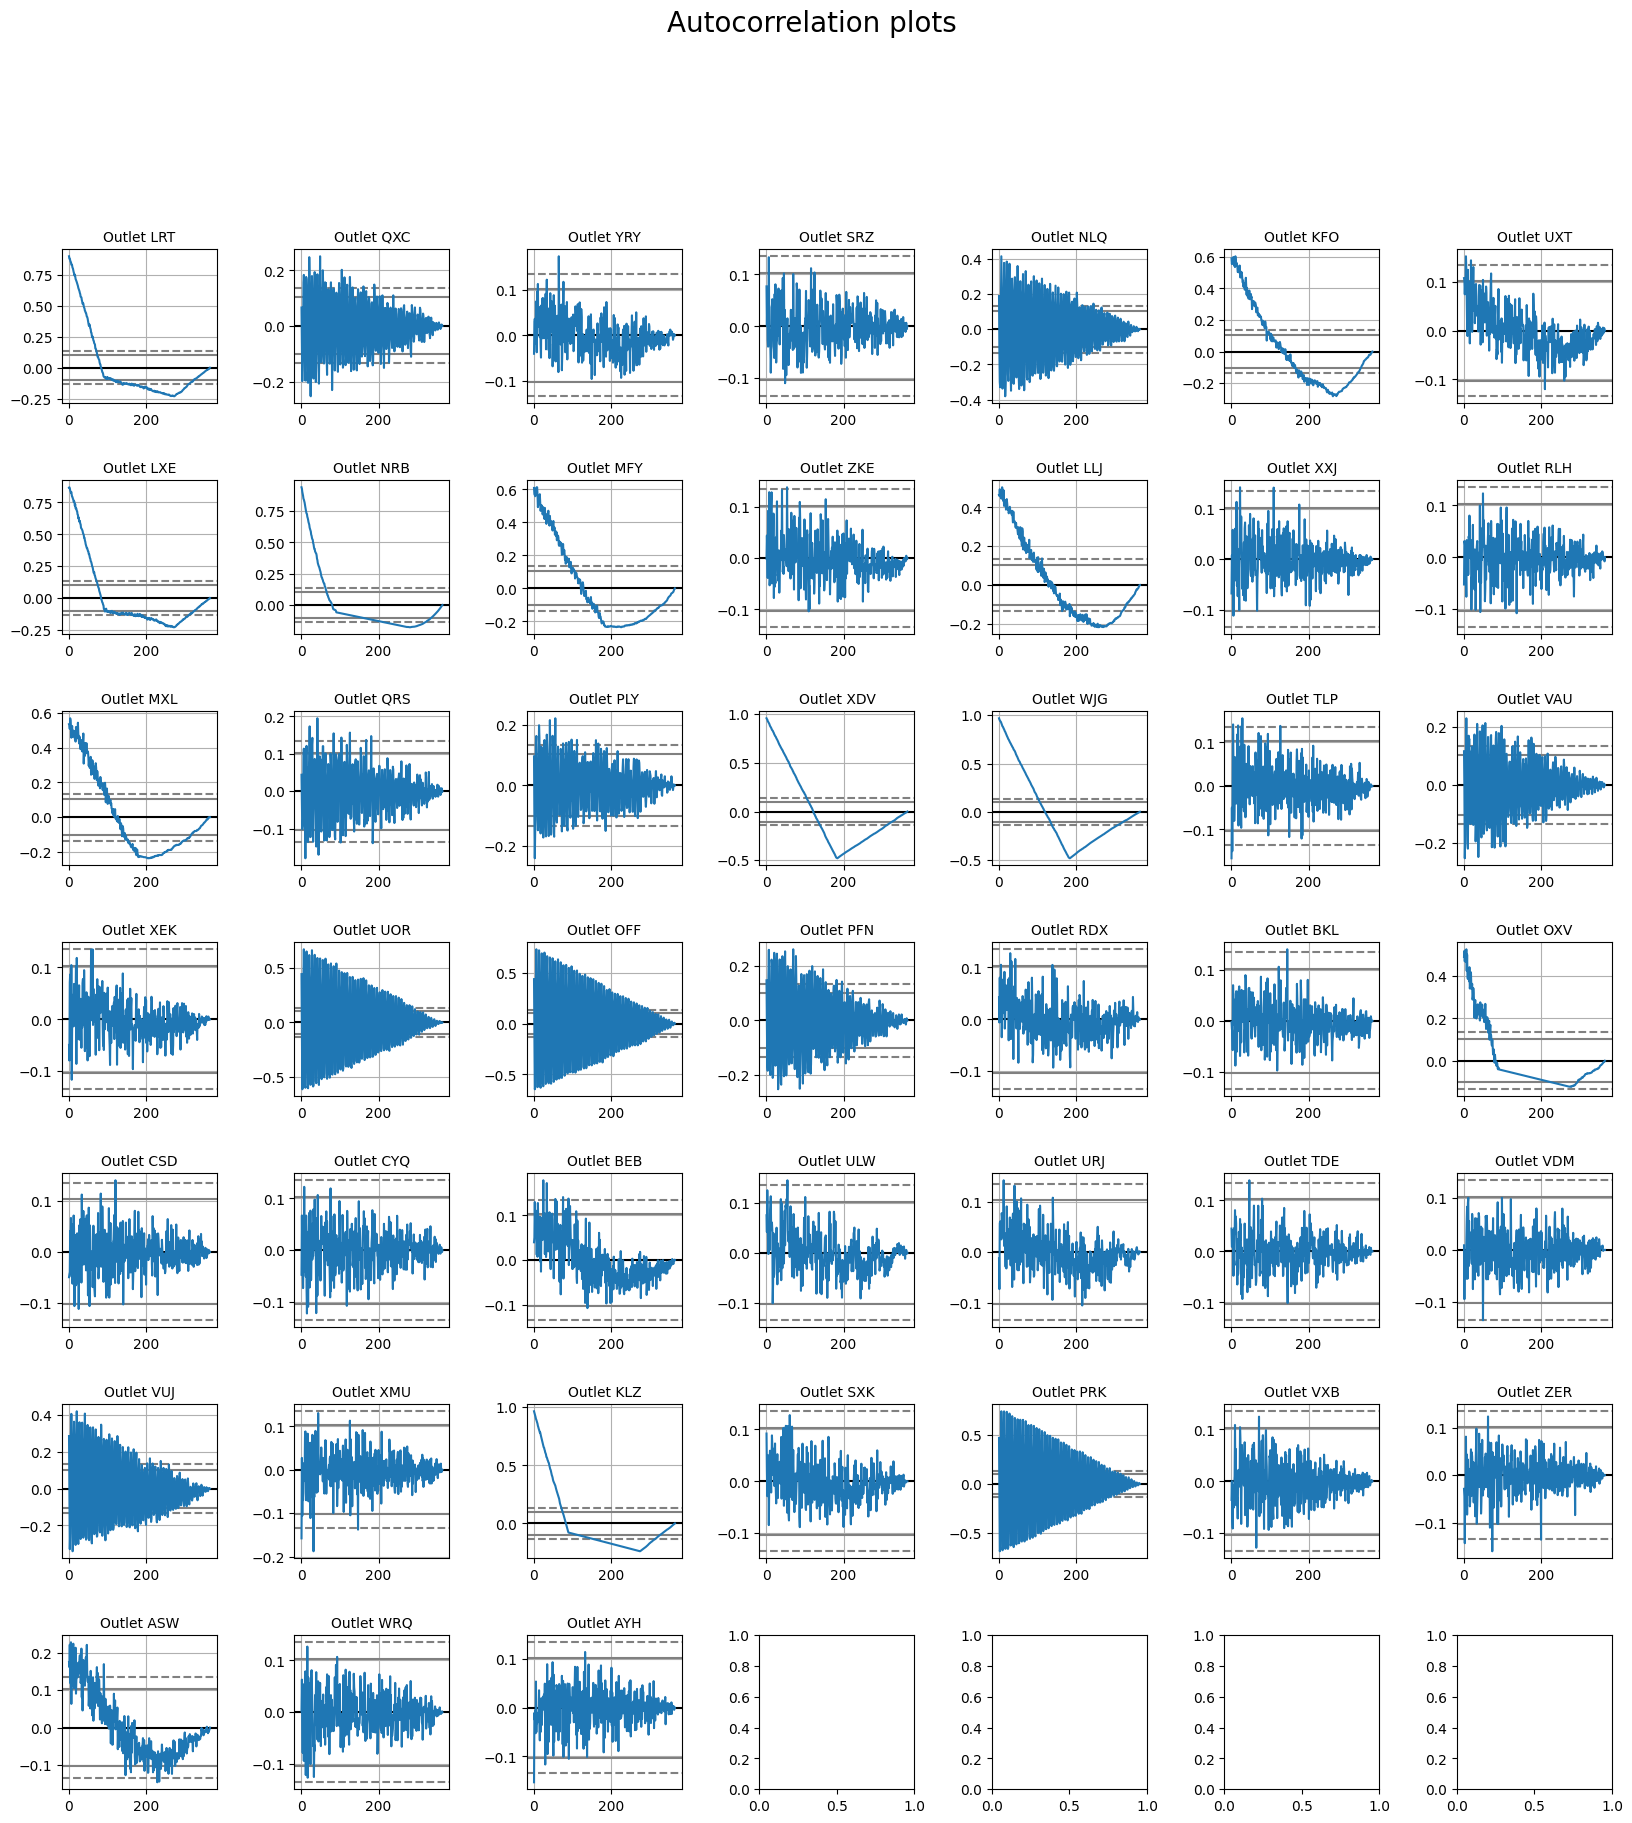

In [ ]:
row = 0
col = 0
fig, axes = plt.subplots(figsize=(20, 20), nrows=7, ncols=7)
fig.suptitle('Autocorrelation plots', fontsize=20, position=(0.5, 1.0))
for name in data.columns:
    sub = pd.plotting.autocorrelation_plot(data[name], axes[row, col])
    sub.set_title('Outlet ' + name, fontsize=10)
    sub.xaxis.label.set_visible(False)
    sub.yaxis.label.set_visible(False)
    col += 1
    if col == 7:
        row += 1
        col = 0
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()